In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install required packages
!pip install transformers torch pandas numpy scikit-learn matplotlib seaborn tqdm


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print("Libraries imported and seeds set!")

Libraries imported and seeds set!


In [5]:
# Load the improved dataset
file_path = '/content/drive/My Drive/improved_fake_news_dataset2.csv'
df = pd.read_csv(file_path)

print("\nDataset Info:")
print(f"Shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"Missing values:\n{df.isnull().sum()}")

# Use text column and labels
texts = df['text'].astype(str).values
labels = df['label'].values

print(f"Class distribution - Fake (0): {(labels == 0).sum()}, Real (1): {(labels == 1).sum()}")

# Split data with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.3, random_state=seed, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp
)

print(f"Data splits:")
print(f"Training set: {len(X_train)}")
print(f"Validation set: {len(X_val)}")
print(f"Test set: {len(X_test)}")


Dataset Info:
Shape: (123954, 4)
Label distribution:
label
1    61977
0    61977
Name: count, dtype: int64
Missing values:
id           0
title    33452
text         0
label        0
dtype: int64
Class distribution - Fake (0): 61977, Real (1): 61977
Data splits:
Training set: 86767
Validation set: 18593
Test set: 18594


In [6]:
# Dataset Class
class ImprovedNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# model configuration
MAX_LENGTH = 256
BATCH_SIZE = 16  #for stability
ACCUMULATION_STEPS = 4  # Gradient accumulation

# Create datasets and dataloaders
train_dataset = ImprovedNewsDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = ImprovedNewsDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = ImprovedNewsDataset(X_test, y_test, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data loaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Data loaders created:
Train batches: 5423
Validation batches: 1163
Test batches: 1163


In [7]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Custom BERT model with class weights
class WeightedBertForSequenceClassification(BertForSequenceClassification):
    def __init__(self, config, class_weights=None):
        super().__init__(config)
        self.class_weights = class_weights

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = super().forward(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            **kwargs
        )

        if labels is not None and self.class_weights is not None:
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(outputs.logits.view(-1, self.num_labels), labels.view(-1))
            outputs.loss = loss

        return outputs

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Class weights: {class_weights}")

Using device: cuda
Class weights: tensor([1.0000, 1.0000], device='cuda:0')


In [8]:
# Initialize BERT model with class weights
model = WeightedBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False,
    class_weights=class_weights
)
model = model.to(device)


print("BERT model initialized with class weights!")

# Improved training parameters
EPOCHS = 4
LEARNING_RATE = 2e-5  # Better for BERT fine-tuning
WARMUP_RATIO = 0.1

# Improved optimizer with weight decay
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters()
                  if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01,
    },
    {
        'params': [p for n, p in model.named_parameters()
                  if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE, eps=1e-8)

# Improved scheduler
total_steps = len(train_loader) * EPOCHS // ACCUMULATION_STEPS
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Training setup completed:")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of WeightedBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model initialized with class weights!
Training setup completed:
Epochs: 4
Learning rate: 2e-05
Total steps: 5423
Warmup steps: 542


In [19]:
!pip install torchinfo

from torchinfo import summary

# Example input shape for BERT
summary(model, input_size=(8, 128), dtypes=[torch.long, torch.long])


Layer (type:depth-idx)                                       Output Shape              Param #
WeightedBertForSequenceClassification                        [8, 2]                    --
├─BertModel: 1-1                                             [8, 768]                  --
│    └─BertEmbeddings: 2-1                                   [8, 128, 768]             --
│    │    └─Embedding: 3-1                                   [8, 128, 768]             23,440,896
│    │    └─Embedding: 3-2                                   [8, 128, 768]             1,536
│    │    └─Embedding: 3-3                                   [1, 128, 768]             393,216
│    │    └─LayerNorm: 3-4                                   [8, 128, 768]             1,536
│    │    └─Dropout: 3-5                                     [8, 128, 768]             --
│    └─BertEncoder: 2-2                                      [8, 128, 768]             --
│    │    └─ModuleList: 3-6                                  --             

In [10]:
# training function with gradient accumulation
def improved_train_epoch(model, data_loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    correct_predictions = 0
    optimizer.zero_grad()

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for i, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss / ACCUMULATION_STEPS
        loss.backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_loss += loss.item() * ACCUMULATION_STEPS

        # Update progress bar
        avg_loss = total_loss / (i + 1)
        current_acc = correct_predictions.double() / ((i + 1) * data_loader.batch_size)
        progress_bar.set_postfix({
            'loss': f'{avg_loss:.4f}',
            'acc': f'{current_acc:.4f}'
        })

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / len(data_loader.dataset)

    return avg_loss, accuracy

# evaluation function
def improved_evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    all_preds = []
    all_labels = []
    all_probs = []

    progress_bar = tqdm(data_loader, desc="Validating", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            probabilities = torch.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)

            correct_predictions += torch.sum(preds == labels)
            total_loss += loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())

            # Update progress bar
            avg_loss = total_loss / (progress_bar.n + 1)
            current_acc = correct_predictions.double() / ((progress_bar.n + 1) * data_loader.batch_size)
            progress_bar.set_postfix({
                'val_loss': f'{avg_loss:.4f}',
                'val_acc': f'{current_acc:.4f}'
            })

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / len(data_loader.dataset)

    return avg_loss, accuracy, all_preds, all_labels, all_probs


In [11]:
print("Starting training...")

# training loop with early stopping
best_val_accuracy = 0
best_model_state = None
patience = 2
patience_counter = 0

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch + 1}/{EPOCHS}')
    print('-' * 50)

    # Training
    train_loss, train_acc = improved_train_epoch(model, train_loader, optimizer, device, scheduler)

    # Validation
    val_loss, val_acc, val_preds, val_labels, val_probs = improved_evaluate_model(model, val_loader, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.cpu().numpy())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.cpu().numpy())

    print(f'Training Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}')

    # Early stopping
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        print("No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

print("Training completed!")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Best model loaded for testing!")

Starting training...

Epoch 1/4
--------------------------------------------------


Training Loss: 0.3138, Accuracy: 0.8405
Validation Loss: 0.2171, Accuracy: 0.8894

Epoch 2/4
--------------------------------------------------


Training Loss: 0.2000, Accuracy: 0.8952
Validation Loss: 0.2119, Accuracy: 0.8909

Epoch 3/4
--------------------------------------------------


Training Loss: 0.1628, Accuracy: 0.9101
Validation Loss: 0.2135, Accuracy: 0.8946

Epoch 4/4
--------------------------------------------------


Training Loss: 0.1402, Accuracy: 0.9200
Validation Loss: 0.2432, Accuracy: 0.8946
No improvement. Patience: {patience_counter}/{patience}
Training completed!
Best model loaded for testing!


In [12]:
# Save the trained model
model_save_path = '/content/drive/MyDrive/improved_fake_news_bert_model10'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/improved_fake_news_bert_model10


Testing: 100%|██████████| 1163/1163 [03:10<00:00,  6.12it/s]



FINAL MODEL PERFORMANCE METRICS
Accuracy:  0.8994
Precision: 0.9054
Recall:    0.8994
F1 Score:  0.8991
ROC-AUC:   0.9718

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Fake News     0.8561    0.9602    0.9052      9297
   Real News     0.9547    0.8387    0.8929      9297

    accuracy                         0.8994     18594
   macro avg     0.9054    0.8994    0.8991     18594
weighted avg     0.9054    0.8994    0.8991     18594



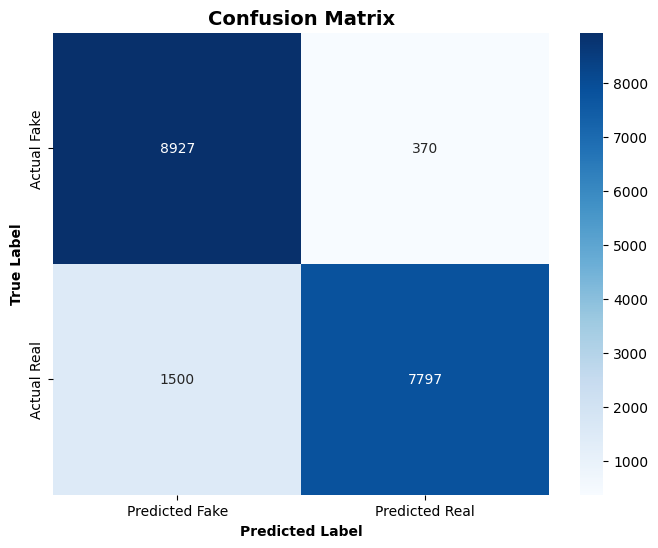

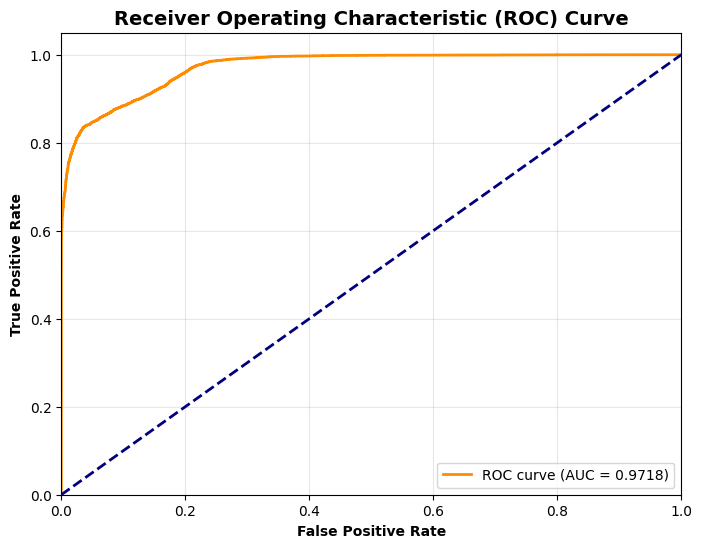

<Figure size 1500x500 with 0 Axes>

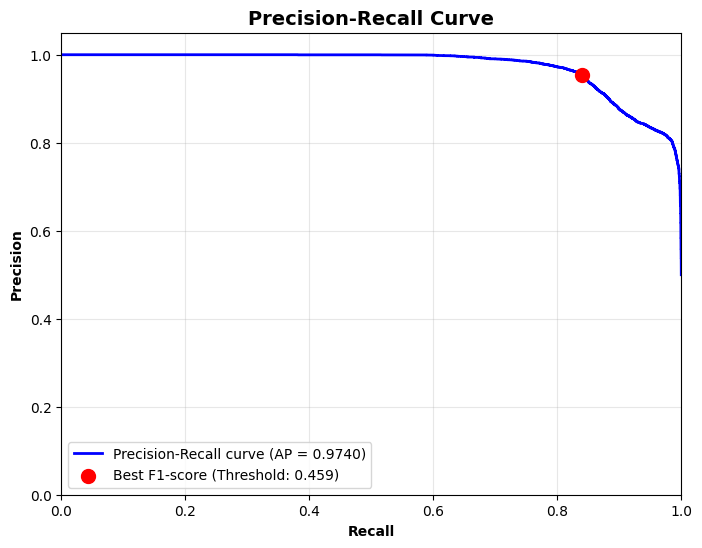

Average Precision (AP): 0.9740
Best F1-Score: 0.8931
Optimal Threshold: 0.4590


In [13]:
# Comprehensive evaluation
def comprehensive_evaluation(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_true_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probabilities = torch.softmax(outputs.logits, dim=1)
            _, predictions = torch.max(outputs.logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    return np.array(all_predictions), np.array(all_probabilities), np.array(all_true_labels)

# Get predictions
y_pred, y_probs, y_true = comprehensive_evaluation(model, test_loader, device)

# Calculate all metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
roc_auc = roc_auc_score(y_true, y_probs[:, 1])

print("\n" + "="*50)
print("FINAL MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=['Fake News', 'Real News'], digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Training History Visualization
plt.figure(figsize=(15, 5))

# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_true, y_probs[:, 1])
average_precision = average_precision_score(y_true, y_probs[:, 1])

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2,
         label=f'Precision-Recall curve (AP = {average_precision:.4f})')
plt.xlabel('Recall', fontweight='bold')
plt.ylabel('Precision', fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# Add a marker for the best F1-score point
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 0.5

plt.scatter(recall[best_f1_idx], precision[best_f1_idx],
            color='red', s=100, zorder=5,
            label=f'Best F1-score (Threshold: {best_threshold:.3f})')
plt.legend(loc="lower left")

plt.show()

print(f"Average Precision (AP): {average_precision:.4f}")
print(f"Best F1-Score: {f1_scores[best_f1_idx]:.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import json

# Ensure scalar (averaged) metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

try:
    roc_auc = roc_auc_score(y_true, y_pred)
except ValueError:
    roc_auc = None  # for multiclass or invalid cases

cm = confusion_matrix(y_true, y_pred)

evaluation_results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(
        y_true, y_pred,
        target_names=['Fake News', 'Real News'],
        output_dict=True
    )
}

results_path = '/content/drive/MyDrive/bert_evaluation_results_improved10.json'
with open(results_path, 'w') as f:
    json.dump(evaluation_results, f, indent=4)

print(f"Evaluation results saved to: {results_path}")

# Final performance summary
print("\n" + "=" * 40)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
if roc_auc is not None:
    print(f"ROC-AUC:   {roc_auc:.4f}")
else:
    print("ROC-AUC:   Not applicable")
print("=" * 40)


Evaluation results saved to: /content/drive/MyDrive/bert_evaluation_results_improved10.json

FINAL PERFORMANCE SUMMARY
Accuracy:  0.8994
Precision: 0.9054
Recall:    0.8994
F1 Score:  0.8991
ROC-AUC:   0.8994
